In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp

import lightgbm as lgb

In [3]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_style("whitegrid")


In [4]:
DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")

train = pd.read_parquet(DATA_PROCESSED / "train.parquet")
val   = pd.read_parquet(DATA_PROCESSED / "val.parquet")
test  = pd.read_parquet(DATA_PROCESSED / "test.parquet")

In [5]:
print(f"Train: {train.shape}, default: {train['TARGET'].mean():.4f}")
print(f"Val:   {val.shape}, default: {val['TARGET'].mean():.4f}")
print(f"Test:  {test.shape}, default: {test['TARGET'].mean():.4f}")

Train: (215257, 123), default: 0.0813
Val:   (46127, 123), default: 0.0798
Test:  (46127, 123), default: 0.0792


In [6]:
# 1. DAYS_EMPLOYED = 365243 is a placeholder for "not employed"
#    A real value of 365243 days = ~1000 years. Obviously fake.
train['DAYS_EMPLOYED_ANOMALY'] = (train['DAYS_EMPLOYED'] == 365243).astype(int)
val['DAYS_EMPLOYED_ANOMALY']   = (val['DAYS_EMPLOYED']   == 365243).astype(int)
test['DAYS_EMPLOYED_ANOMALY']  = (test['DAYS_EMPLOYED']  == 365243).astype(int)

In [7]:
for df in [train, val, test]:
    df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

In [8]:
# 2. Check how many rows are affected
print(f"Train: {train['DAYS_EMPLOYED_ANOMALY'].sum()} unemployed applicants "
      f"({train['DAYS_EMPLOYED_ANOMALY'].mean()*100:.2f}%)")
print(f"Val:   {val['DAYS_EMPLOYED_ANOMALY'].sum()} unemployed applicants "
      f"({val['DAYS_EMPLOYED_ANOMALY'].mean()*100:.2f}%)")
print(f"Test:  {test['DAYS_EMPLOYED_ANOMALY'].sum()} unemployed applicants "
      f"({test['DAYS_EMPLOYED_ANOMALY'].mean()*100:.2f}%)")

Train: 38783 unemployed applicants (18.02%)
Val:   8366 unemployed applicants (18.14%)
Test:  8225 unemployed applicants (17.83%)


In [9]:
print("\nDefault rate by employment status (train):")
print(train.groupby('DAYS_EMPLOYED_ANOMALY')['TARGET'].agg(['mean', 'count']))


Default rate by employment status (train):
                           mean   count
DAYS_EMPLOYED_ANOMALY                  
0                      0.087067  176474
1                      0.054818   38783


In [10]:
def add_ratio_features(df):
    df = df.copy()
    
    # Credit-to-income: "how many years of income is this loan?"
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    
    # Annuity-to-income: monthly debt burden
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    
    # Credit term: number of months of payments
    df['CREDIT_TERM_MONTHS'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
    
    # Employment-to-age: fraction of life spent employed
    df['EMPLOYED_AGE_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    
    # Credit-to-goods price: how much of purchase price is financed
    df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
    
    # Income per family member
    df['INCOME_PER_FAMILY'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    
    # Income per child (with safe handling for zero children)
    df['INCOME_PER_CHILD'] = df['AMT_INCOME_TOTAL'] / (df['CNT_CHILDREN'] + 1)
    
    return df

In [11]:
train = add_ratio_features(train)
val   = add_ratio_features(val)
test  = add_ratio_features(test)

In [12]:
print(f"After ratio features: {train.shape}")
print(f"Val:   {val.shape}")
print(f"Test:  {test.shape}")

After ratio features: (215257, 131)
Val:   (46127, 131)
Test:  (46127, 131)


In [13]:
def add_ext_source_features(df):
    df = df.copy()
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    
    df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_STD']  = df[ext_cols].std(axis=1)
    df['EXT_SOURCE_MIN']  = df[ext_cols].min(axis=1)
    df['EXT_SOURCE_MAX']  = df[ext_cols].max(axis=1)
    df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    
    return df

In [14]:
train = add_ext_source_features(train)
val   = add_ext_source_features(val)
test  = add_ext_source_features(test)

In [15]:
def add_document_count(df):
    df = df.copy()
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    df['DOCUMENT_COUNT'] = df[doc_cols].sum(axis=1)
    return df

In [17]:
train = add_document_count(train)
val   = add_document_count(val)
test  = add_document_count(test)

print(f"Documents counted: {len([c for c in train.columns if c.startswith('FLAG_DOCUMENT_')])}")
print(f"Documents counted: {len([c for c in val.columns if c.startswith('FLAG_DOCUMENT_')])}")
print(f"Documents counted: {len([c for c in test.columns if c.startswith('FLAG_DOCUMENT_')])}")

Documents counted: 20
Documents counted: 20
Documents counted: 20


In [21]:
# Identify categorical columns
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")
# Cardinality check — how many unique values per categorical?
cardinality = train[cat_cols].nunique().sort_values(ascending=False)
print("\nCategorical cardinality:")
print(cardinality)


Categorical columns: 16

Categorical cardinality:
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64


C:\Users\rohit\AppData\Local\Temp\ipykernel_16912\3496394452.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()


In [22]:
def target_encode(train_df, other_dfs, col, target='TARGET', smoothing=20):
    """
    Smooth target encoding:
      encoded_value = (sum_target + prior * smoothing) / (count + smoothing)
    
    Fit on train. Transform val/test using the same mapping.
    Unknown categories in val/test get the prior (train mean).
    """
    prior = train_df[target].mean()
    
    agg = train_df.groupby(col)[target].agg(['mean', 'count'])
    smoothed = (agg['mean'] * agg['count'] + prior * smoothing) / (agg['count'] + smoothing)
    
    # Apply to train
    train_df[f'{col}_TE'] = train_df[col].map(smoothed).fillna(prior)
    
    # Apply to others
    for other in other_dfs:
        other[f'{col}_TE'] = other[col].map(smoothed).fillna(prior)
    
    return train_df, other_dfs

In [24]:
# Combine engineered features back into each split, convert categoricals to category dtype
def prep_for_lgb(df, cat_cols):
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].astype('category')
    return df

train_lgb = prep_for_lgb(train, cat_cols)
val_lgb   = prep_for_lgb(val,   cat_cols)
test_lgb  = prep_for_lgb(test,  cat_cols)

# Feature list: everything except TARGET and the ID
feature_cols = [c for c in train_lgb.columns if c not in ['TARGET', 'SK_ID_CURR']]

X_train = train_lgb[feature_cols]
y_train = train_lgb['TARGET']
X_val   = val_lgb[feature_cols]
y_val   = val_lgb['TARGET']
X_test  = test_lgb[feature_cols]
y_test  = test_lgb['TARGET']

print(f"Features: {len(feature_cols)}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Features: 135
X_train: (215257, 135), X_val: (46127, 135), X_test: (46127, 135)


In [25]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'is_unbalance': True,   # handles class imbalance
    'verbose': -1,
    'random_state': 42
}

lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_cols)
lgb_val   = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=cat_cols)

model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)


Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.794003	val's auc: 0.767036
[200]	train's auc: 0.81894	val's auc: 0.769924
Early stopping, best iteration is:
[221]	train's auc: 0.823237	val's auc: 0.770168


In [26]:
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    auc = roc_auc_score(y, y_pred)
    ks, _ = ks_2samp(y_pred[y==1], y_pred[y==0])
    brier = brier_score_loss(y, y_pred)
    print(f"{name:6s} | AUC: {auc:.4f} | KS: {ks:.4f} | Brier: {brier:.4f}")
    return y_pred

print("LightGBM performance:")
_ = evaluate(model, X_train, y_train, "train")
_ = evaluate(model, X_val, y_val, "val")
_ = evaluate(model, X_test, y_test, "test")

LightGBM performance:
train  | AUC: 0.8232 | KS: 0.4853 | Brier: 0.1781
val    | AUC: 0.7702 | KS: 0.4162 | Brier: 0.1823
test   | AUC: 0.7648 | KS: 0.3943 | Brier: 0.1851


In [27]:
# Simple pipeline: impute -> scale -> logistic
num_cols = [c for c in feature_cols if c not in cat_cols]

lr_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Logistic needs numeric features — use only numeric for now (simpler than encoding categoricals)
lr_pipeline.fit(X_train[num_cols], y_train)

lr_pred_val = lr_pipeline.predict_proba(X_val[num_cols])[:, 1]
lr_pred_test = lr_pipeline.predict_proba(X_test[num_cols])[:, 1]

print(f"Logistic | Val AUC: {roc_auc_score(y_val, lr_pred_val):.4f} | "
      f"Test AUC: {roc_auc_score(y_test, lr_pred_test):.4f}")

Logistic | Val AUC: 0.7491 | Test AUC: 0.7409


Top 25 features by gain:
               feature          gain  split
       EXT_SOURCE_MEAN 347958.376274    190
     ORGANIZATION_TYPE 139299.064697   1220
    CREDIT_TERM_MONTHS  74231.551672    490
        EXT_SOURCE_MAX  39126.268753     93
          EXT_SOURCE_3  36608.116856    206
    CREDIT_GOODS_RATIO  32219.826614    156
        EXT_SOURCE_MIN  28404.044979    132
       OCCUPATION_TYPE  25613.280201    220
         DAYS_EMPLOYED  20725.124311    122
       EXT_SOURCE_PROD  19581.142941    120
           OWN_CAR_AGE  18833.019547    122
        EXT_SOURCE_STD  17809.378788     87
       AMT_GOODS_PRICE  17770.455677    123
           AMT_ANNUITY  17241.939674    134
    EMPLOYED_AGE_RATIO  16486.046871    128
          EXT_SOURCE_1  15982.147511    146
       DAYS_ID_PUBLISH  14338.577602    146
            AMT_CREDIT  14306.908489    131
   NAME_EDUCATION_TYPE  12801.735912     42
           CODE_GENDER  12684.139160     61
          EXT_SOURCE_2  11556.343571    119
       

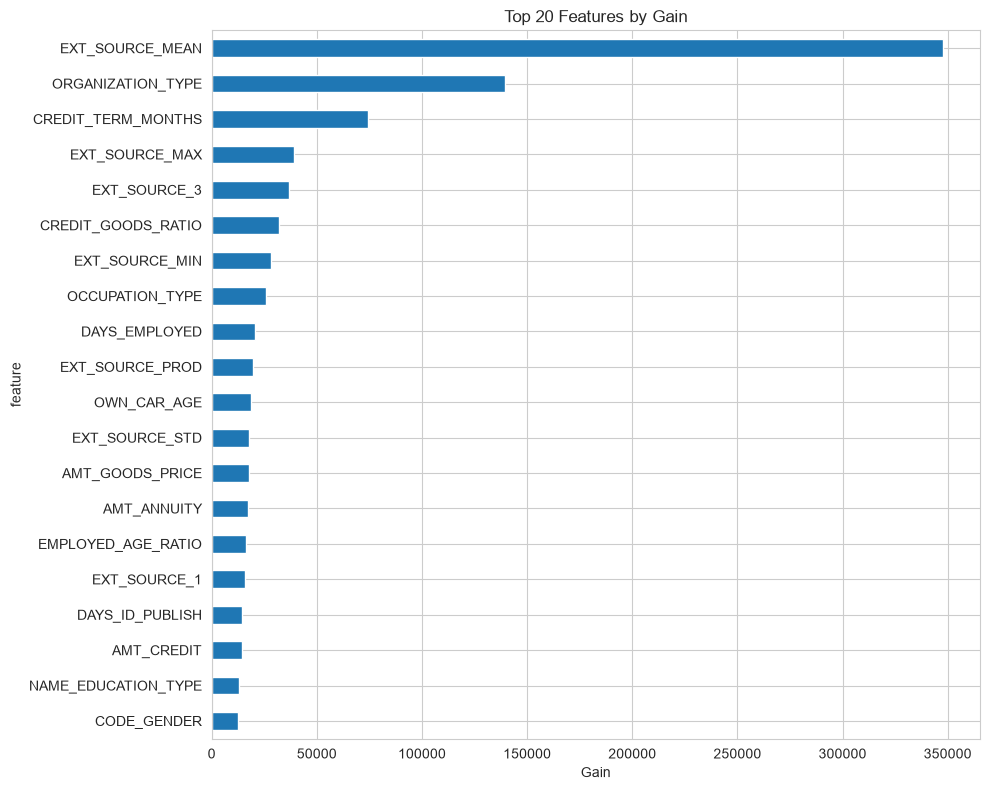

In [28]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'gain': model.feature_importance(importance_type='gain'),
    'split': model.feature_importance(importance_type='split')
}).sort_values('gain', ascending=False)

print("Top 25 features by gain:")
print(importance.head(25).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).iloc[::-1].plot(kind='barh', x='feature', y='gain', ax=ax, legend=False)
ax.set_title('Top 20 Features by Gain')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

In [29]:
import pickle

MODELS_DIR.mkdir(exist_ok=True)
model.save_model(str(MODELS_DIR / "lgb_v1.txt"))

with open(MODELS_DIR / "lr_v1.pkl", "wb") as f:
    pickle.dump(lr_pipeline, f)

print("Saved models")

Saved models
